# Project: the finite amplitude method for the RPA

Companion notebook to Appendix A, Project 1, of *Quantum mechanics for
many-particle systems*.  The code is the same as in
`BookManybody/BookPrograms/appendixA/fam.py`, which builds on the
chapter-7 program `rpa.py`.

The random-phase approximation of Chapter 7 was solved by constructing the
matrices $A$ and $B$ and diagonalising
$\begin{pmatrix}A & B\\ -B^* & -A^*\end{pmatrix}$.  The **finite amplitude
method** of Nakatsukasa, Inakura and Yabana, Phys. Rev. C **76**, 024318
(2007), solves the same linear-response problem without ever forming $A$ and
$B$: it needs only the mean-field routine $h[\rho]$ of a static Hartree-Fock
code, evaluated for a density built from *independent* bra and ket orbitals.

For a fixed, in general complex, frequency $\omega$ and an external one-body
field $\hat F$, the forward and backward amplitudes $X_{mi}(\omega)$ and
$Y_{mi}(\omega)$ satisfy

$$(\omega-\varepsilon_m+\varepsilon_i)\,X_{mi}-\delta h_{mi}(\omega)=F_{mi},
\qquad
(-\omega-\varepsilon_m+\varepsilon_i)\,Y_{mi}-\delta h_{im}(\omega)=F_{im},$$

where the induced field is evaluated as the finite difference

$$\delta h(\omega)=\frac{1}{\eta}\Big(h\big[\langle\psi'|,|\psi\rangle\big]-h_0\Big),
\qquad
|\psi_i\rangle=|\phi_i\rangle+\eta|X_i\rangle,\quad
\langle\psi'_i|=\langle\phi_i|+\eta\langle Y_i|,$$

with $\rho=\sum_i|\psi_i\rangle\langle\psi'_i|$ non-Hermitian.  The strength
function follows from the amplitudes,

$$S(F;\omega)=\sum_i\Big(\langle\phi_i|\hat F^\dagger|X_i\rangle
  +\langle Y_i|\hat F^\dagger|\phi_i\rangle\Big),\qquad
\frac{dB(F;\omega)}{d\omega}=-\frac{1}{\pi}\,{\rm Im}\,S(F;\omega+i\Gamma/2).$$

The paper applies this to the deformed nucleus $^{20}$Ne with the BKN
functional on a three-dimensional mesh.  That calculation needs a
coordinate-space Hartree-Fock code the book does not have; every
*methodological* result of the paper, however, can be reproduced on the
pairing plus particle-hole model of Chapter 7 -- and, because the model can
be diagonalised exactly, compared with the exact response as well.

Contents:

1. The mean field and the particle-hole space
2. The induced field by finite differences: the $\eta$ trade-off
3. Strength functions: exact, matrix RPA and FAM
4. Sum rules and poles by contour integration
5. The cost: iterations against frequency and smoothing

In [1]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt

# the chapter programs live in BookPrograms/chapterNN and the project
# programs in BookPrograms/appendixA; put them all on the path
for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import rpa
import fam

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. The mean field and the particle-hole space

The class `MeanField` plays the role of the static Hartree-Fock program: it
knows how to build $h[\rho]=t+\sum_{cd}\bar v_{acbd}\rho_{dc}$ from a one-body
density and nothing about the RPA.  The single extension the finite amplitude
method asks for is `h_braket(bra, ket)`, which accepts independent bra and ket
orbitals.  We work at $g=1$, $f=0.5$, the most strongly coupled case of
Chapter 7, where the residual interaction shifts the lowest particle-hole
energy by about ten per cent.

In [2]:
fam.demo_setup()

1. The mean field and the particle-hole space
L = 4 levels, N = 4 particles, g = 1.0, f = 0.5
E_HF = -0.269764
HF single-particle energies: -1.5052  -1.5052   0.1194   0.1194   1.9305   1.9305   2.9534   2.9534
particle-hole pairs: 16, unperturbed energies [1.8111 2.834  3.4357 4.4586]

h[rho] returns the HF energies when fed the HF density:
  max |h0 - diag(eps)| = 9.5e-14
and it is linear in rho, so the finite difference is exact up to
the quadratic term of rho = sum |psi><psi'| and to round-off.


## 2. The induced field by finite differences

Because $h[\rho]$ is linear in $\rho$ for this model, $\delta h$ could be
evaluated exactly as $(\partial h/\partial\rho)\,\delta\rho$ -- the
conventional route, which the class `MatrixResponse` follows with the $A$ and
$B$ of Chapter 7.  The finite difference of the paper is nevertheless not
exact: the density built from the perturbed bra and ket orbitals,

$$\rho_\eta=\rho_0+\eta\,\delta\rho+\eta^2\sum_i|X_i\rangle\langle Y_i|,$$

carries a quadratic term, so the forward difference has an $O(\eta)$ error,
and the round-off in $h[\rho_\eta]-h_0$ grows as $1/\eta$.  A central
difference removes the quadratic term.  The demonstration below checks all of
this against the explicit $A$ and $B$ and then solves the FAM equations at two
frequencies with three different solvers.

In [3]:
fam.demo_validation()

2. FAM against the RPA matrix, one frequency at a time
The induced field from finite differences against (dh/drho) drho,
for a random amplitude vector:
  max |dh(linear) - (A - Delta)X - BY| = 1.0e-13
  forward  eta = 1e-02:  max |dh - dh(linear)| = 1.4e-02
  forward  eta = 1e-04:  max |dh - dh(linear)| = 1.4e-04
  forward  eta = 1e-06:  max |dh - dh(linear)| = 1.4e-06
  forward  eta = 1e-08:  max |dh - dh(linear)| = 9.5e-08
  central  eta = 1e-02:  max |dh - dh(linear)| = 3.5e-14
  central  eta = 1e-04:  max |dh - dh(linear)| = 4.3e-12
  central  eta = 1e-06:  max |dh - dh(linear)| = 5.3e-10
  central  eta = 1e-08:  max |dh - dh(linear)| = 5.9e-08

The forward difference carries the O(eta) error of the term
eta^2 sum_i |X_i><Y_i| in the density; the central difference
cancels it, and both eventually lose to round-off, which grows as
1/eta.  This is the finite-difference trade-off of the paper.


Strength function at omega = (1.7+0.05j):
  RPA matrix, linear solve      S = 0.1874033580

TypeError: gmres() got an unexpected keyword argument 'rtol'

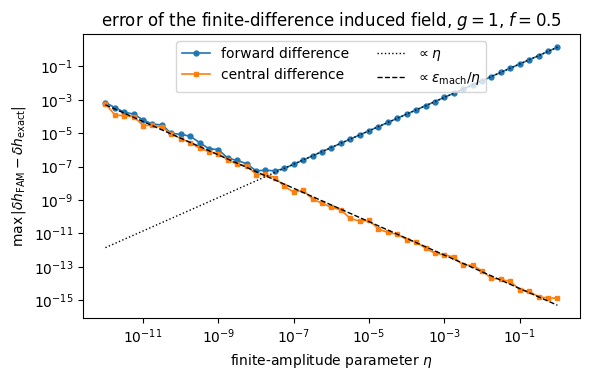

In [4]:
fock, mf = fam.setup()
matrix = fam.MatrixResponse(mf)
rng = np.random.default_rng(1)
n = matrix.space.size
X = rng.normal(size=n) + 1j * rng.normal(size=n)
Y = rng.normal(size=n) + 1j * rng.normal(size=n)
dh_lin = fam.FiniteAmplitudeMethod(mf, scheme="linear").induced_field(X, Y)
etas = np.logspace(-12, 0, 49)
fig, ax = plt.subplots(figsize=(6.0, 3.9))
for scheme, marker in (("forward", "o"), ("central", "s")):
    err = [np.abs(fam.FiniteAmplitudeMethod(mf, eta=eta, scheme=scheme)
                  .induced_field(X, Y) - dh_lin).max() for eta in etas]
    ax.loglog(etas, err, marker=marker, ms=3.5, lw=1.2, label=scheme + " difference")
ax.loglog(etas, 1.4 * etas, "k:", lw=1, label=r"$\propto\eta$")
ax.loglog(etas, 5e-16 / etas, "k--", lw=1, label=r"$\propto\epsilon_{\rm mach}/\eta$")
ax.set_xlabel(r"finite-amplitude parameter $\eta$")
ax.set_ylabel(r"$\max\,|\delta h_{\rm FAM}-\delta h_{\rm exact}|$")
ax.set_title(r"error of the finite-difference induced field, $g=1$, $f=0.5$")
ax.legend(loc="upper center", ncol=2)
fig.tight_layout(); plt.show()

The forward difference is what the paper uses, with $\eta=10^{-5}$: the
error is then of order $10^{-5}$, which is the origin of the "three to four
digits" of agreement between FAM and RPA reported there.  The central
difference is exact down to round-off for a Hamiltonian linear in the density;
for a density-dependent functional such as BKN or Skyrme it would still leave
an $O(\eta^2)$ error, at the price of two evaluations of $h$ per iteration.

## 3. Strength functions: exact, matrix RPA and FAM

Two external fields are natural in the model: the level operator
$\hat Q_0=\sum_{p\sigma}(p-1)\,\hat n_{p\sigma}=\hat H_0/\xi$, the discrete
analogue of a monopole field, and the hopping operator
$\hat Q_1=\sum_{p\sigma}(\hat a^\dagger_{p+1\sigma}\hat a_{p\sigma}+{\rm h.c.})$,
the analogue of a dipole field, which breaks pairs.  For each we compute
$dB/d\omega$ with a smoothing $\Gamma=0.1$ from the exact eigenstates of the
$N=4$ system, from the RPA matrix, and from the finite amplitude method.

In [5]:
fam.demo_strength()

3. Strength functions: exact, RPA matrix and FAM


smoothing Gamma = 0.1, i.e. omega -> omega + i Gamma/2

  level operator Q_0
   omega        exact          RPA          FAM  |FAM-RPA|  iter
    0.50     0.001546     0.000966     0.000966    1.1e-08    16
    1.00     0.003517     0.003208     0.003208    3.4e-08    16
    1.50     0.006756     0.043601     0.043601    5.8e-07    16
    1.70     0.008868     0.177094     0.177094    4.5e-07    16
    2.00     0.014082     0.012197     0.012197    1.8e-08    16
    2.50     0.044676     0.024760     0.024760    1.6e-07    16
    3.00     1.036885     0.131015     0.131013    1.5e-06    16
    3.50     0.099828     0.044469     0.044469    1.5e-07    16
  RPA roots       : [1.6445 2.7279 3.176  4.2588]
  exact excitations with strength > 1e-3: [ 2.8596  3.0986  3.7301  4.2292  4.5498  5.2405  5.8731  5.944   6.552   8.0838  8.1885  8.2764  8.5887  9.1274
  9.2594 10.1426 10.7073]

  hopping operator Q_1
   omega        exact          RPA          FAM  |FAM-RPA|  iter
    0.50     0.003

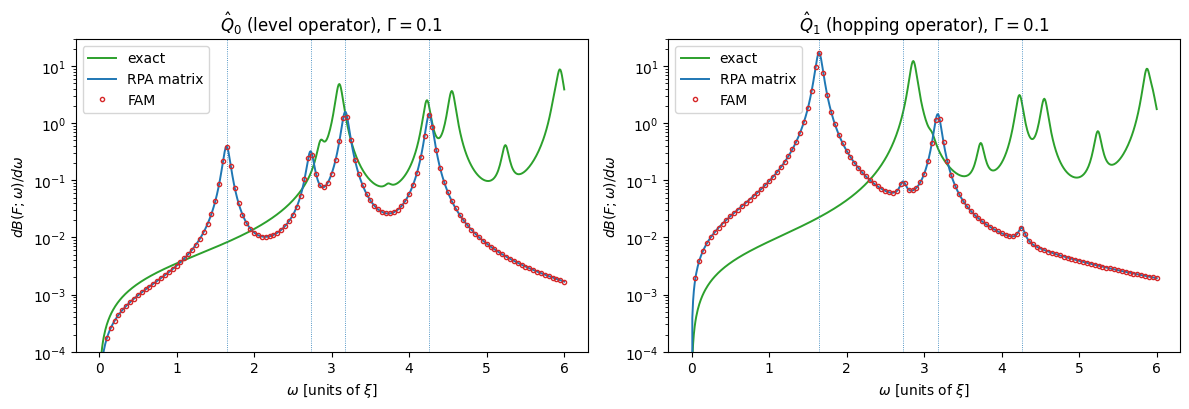

In [6]:
fock, mf = fam.setup()
matrix = fam.MatrixResponse(mf)
exact = fam.ExactResponse(fock, mf.N, mf.g, mf.f)
fam_fwd = fam.FiniteAmplitudeMethod(mf)
gamma = 0.1
omegas = np.linspace(0.0, 6.0, 601)
omegas_fam = np.linspace(0.05, 6.0, 120)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for panel, (name, F0) in enumerate((("$\\hat Q_0$ (level operator)", fam.field_level(fock.L)),
                                    ("$\\hat Q_1$ (hopping operator)", fam.field_hopping(fock.L)))):
    F = mf.to_hf_basis(F0)
    ax[panel].plot(omegas, fam.strength_curve(exact.strength, F0, omegas, gamma),
                   color="C2", lw=1.4, label="exact")
    ax[panel].plot(omegas, fam.strength_curve(matrix.strength, F, omegas, gamma),
                   color="C0", lw=1.4, label="RPA matrix")
    ax[panel].plot(omegas_fam, fam.strength_curve(fam_fwd.strength, F, omegas_fam, gamma),
                   "o", color="C3", ms=3, mfc="none", label="FAM")
    for w in np.unique(np.round(matrix.omega, 6)):
        ax[panel].axvline(w, color="C0", lw=0.6, ls=":")
    ax[panel].set_xlabel(r"$\omega$ [units of $\xi$]")
    ax[panel].set_ylabel(r"$dB(F;\omega)/d\omega$")
    ax[panel].set_title(rf"{name}, $\Gamma={gamma}$")
    ax[panel].set_yscale("log"); ax[panel].set_ylim(1e-4, 30)
    ax[panel].legend(loc="upper left")
fig.tight_layout(); plt.show()

The FAM points sit on the matrix-RPA curve to the accuracy of the finite
difference, at every frequency and for both operators: this is the content of
Fig. 1 of the paper, reproduced on a system where nothing is hidden.  The
dotted vertical lines mark the four distinct RPA roots (each is four-fold
degenerate in this model).

The exact response is another matter.  At $g=1$, $f=0.5$ the exact ground
state is strongly correlated -- Chapter 7 found the RPA correlation energy far
from the exact one here -- and its strength sits at higher energies and is
spread over many states that RPA, with its single particle-hole pair, cannot
reach.  The finite amplitude method reproduces the RPA, no more and no less;
whether the RPA is adequate is a separate question, and the model answers it
honestly.

## 4. Sum rules and poles by contour integration

The energy-weighted sum rule $m_1=\sum_\nu\omega_\nu|\langle\nu|\hat F|0\rangle|^2
=\tfrac12\langle 0|[\hat F,[\hat H,\hat F]]|0\rangle$ holds for the exact
states, and -- Thouless' theorem -- for the self-consistent RPA with the
Hartree-Fock state on the right-hand side.  Both double commutators are
evaluated with the `build_AB` routine of Chapter 7.

The strength function is a meromorphic function of $\omega$ with simple poles
at the RPA roots, so its contour integrals return the moments of the enclosed
poles,

$$\frac{1}{2\pi i}\oint_C S(F;\omega)\,d\omega=\sum_{\nu\in C}|\langle\nu|\hat F|0\rangle|^2,
\qquad
\frac{1}{2\pi i}\oint_C \omega\,S(F;\omega)\,d\omega=\sum_{\nu\in C}\omega_\nu|\langle\nu|\hat F|0\rangle|^2,$$

and the ratio locates a single enclosed pole.  Each quadrature point is one
FAM solution at a complex frequency, with no smoothing at all.

The same idea gives the RPA correlation energy of Chapter 7,
$E^{\rm RPA}_{\rm corr}=\tfrac12(\sum_\nu\omega_\nu-{\rm Tr}\,A)$, without
the matrix $A$: for the unit field $\hat F_K=\hat a^\dagger_m\hat a_i$ the
strength function has the residue $|X^\nu_K|^2$ at $+\omega_\nu$ and
$-|Y^\nu_K|^2$ at $-\omega_\nu$, so that, with a circle $C_+$ around the
positive roots and its mirror image $C_-$,

$$\sum_\nu\omega_\nu=\sum_K\Big[\frac{1}{2\pi i}\oint_{C_+}\omega S(F_K;\omega)\,d\omega
-\frac{1}{2\pi i}\oint_{C_-}\omega S(F_K;\omega)\,d\omega\Big]$$

by the normalisation $\sum_K(|X^\nu_K|^2-|Y^\nu_K|^2)=1$, while
$A_{KK}=\Delta_K+\delta h_K[X=e_K,Y=0]$ is one induced field per pair.

In [7]:
fam.demo_sum_rules()

4. Sum rules and the poles by contour integration


  field Q_0
    RPA   m0 = 0.58342157  m1 = 1.98184275   (1/2)<HF|[F,[H,F]]|HF> = 1.98184275
    exact m0 = 3.58821259  m1 = 18.35650026   (1/2)<0|[F,[H,F]]|0>   = 18.35650026
    contour around omega_1 with  8 points: m0 = 0.06117085, m1/m0 = 1.64452806   (omega_1 = 1.64448414)
    contour around omega_1 with 16 points: m0 = 0.06116866, m1/m0 = 1.64448506   (omega_1 = 1.64448414)
    contour around omega_1 with 32 points: m0 = 0.06116866, m1/m0 = 1.64448506   (omega_1 = 1.64448414)
    the same with the central difference:    m0 = 0.06116884, m1/m0 = 1.64448414


    contour enclosing every positive root:  m0 = 0.58342072  m1 = 1.98184263
  field Q_1
    RPA   m0 = 2.91761894  m1 = 5.15401024   (1/2)<HF|[F,[H,F]]|HF> = 5.15401024
    exact m0 = 5.66687100  m1 = 27.80182051   (1/2)<0|[F,[H,F]]|0>   = 27.80182051
    contour around omega_1 with  8 points: m0 = 2.68386483, m1/m0 = 1.64448482   (omega_1 = 1.64448414)
    contour around omega_1 with 16 points: m0 = 2.68386410, m1/m0 = 1.64448442   (omega_1 = 1.64448414)
    contour around omega_1 with 32 points: m0 = 2.68386415, m1/m0 = 1.64448443   (omega_1 = 1.64448414)
    the same with the central difference:    m0 = 2.68386470, m1/m0 = 1.64448414


    contour enclosing every positive root:  m0 = 2.91761644  m1 = 5.15401130

The RPA correlation energy from contour integrals of the FAM
strength functions of the sixteen unit fields a^+_m a_i:


  forward  sum omega = 47.22841931  Tr A = 50.15811508  E_corr = -1.46484789


  central  sum omega = 47.22841931  Tr A = 50.15811508  E_corr = -1.46484789
  chapter 7 sum omega = 47.22841931  Tr A = 50.15811508  E_corr = -1.46484788

Thouless' theorem holds for the self-consistent RPA: the energy-
weighted sum of the RPA strengths equals the double commutator in
the Hartree-Fock state.  The contour integrals of the FAM strength
function return both moments without any smoothing, and the ratio
of the two locates the pole -- to the accuracy of the finite
difference, and to ten digits with the central one -- from a
solver that has never seen the matrices A and B.


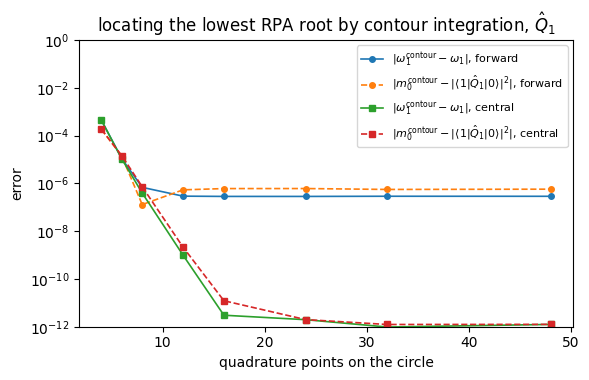

In [8]:
fock, mf = fam.setup()
matrix = fam.MatrixResponse(mf)
F = mf.to_hf_basis(fam.field_hopping(fock.L))
w1 = matrix.omega[0]
t_all = np.abs(matrix.transition_amplitudes(F))**2
t1 = np.sum(t_all[np.abs(matrix.omega - w1) < 1e-6])
npts = np.array([4, 6, 8, 12, 16, 24, 32, 48])
fig, ax = plt.subplots(figsize=(6.0, 3.9))
for scheme, marker in (("forward", "o"), ("central", "s")):
    solver = fam.FiniteAmplitudeMethod(mf, scheme=scheme)
    err_w, err_m = [], []
    for npt in npts:
        m0, m1 = fam.contour_moments(lambda z: solver.strength(F, z),
                                     center=w1, radius=0.3, npoints=npt)
        err_w.append(abs((m1 / m0).real - w1))
        err_m.append(abs(m0.real - t1))
    ax.semilogy(npts, err_w, marker=marker, ms=4, lw=1.2,
                label=rf"$|\omega_1^{{\rm contour}}-\omega_1|$, {scheme}")
    ax.semilogy(npts, err_m, marker=marker, ms=4, lw=1.2, ls="--",
                label=rf"$|m_0^{{\rm contour}}-|\langle 1|\hat Q_1|0\rangle|^2|$, {scheme}")
ax.set_xlabel("quadrature points on the circle")
ax.set_ylabel("error")
ax.set_ylim(1e-12, 1)
ax.set_title(r"locating the lowest RPA root by contour integration, $\hat Q_1$")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

The trapezoidal rule on a circle converges exponentially, and the floor it
reaches is set by the finite difference: about $10^{-6}$ for the forward
scheme with $\eta=10^{-5}$, round-off for the central one.  This is how the
finite amplitude method is used in practice to extract discrete RPA modes and
their transition strengths without a diagonalisation (Hinohara, Kortelainen
and Nazarewicz, Phys. Rev. C **87**, 064309 (2013)).

## 5. The cost: iterations against frequency and smoothing

The FAM equations are linear in $(X,Y)$ and are solved iteratively.  The
paper uses a bi-conjugate-gradient solver and reports that the number of
iterations grows with $\omega$ and with decreasing $\Gamma$.  In the model the
unknowns number $2\times16$, so a Krylov solver converges in a handful of
steps whatever $\omega$ is; the plain iteration
$X\leftarrow(F+\delta h)/(\omega-\Delta)$ with mixing, on the other hand,
shows the trend of the paper clearly -- it slows down as the frequency
approaches a pole and as $\Gamma$ shrinks, and it can fail altogether.

In [9]:
fam.demo_iterations()

5. The cost: iterations against frequency and smoothing
 omega   gmres G=0.5   fixed G=0.5    gmres G=0.2   fixed G=0.2    gmres G=0.05  fixed G=0.05
  0.50             16           48              16           49              16           49 
  1.00             16           54              16           56              16           56 
  1.50             16           78              16          105              16          115 
  1.65             16           92 

             16          360 

             16         3000*
  2.00              8           44               8           43               8           38 
  2.70              8           55               8          102               8          202 
  3.20              8          153 

             16         3000*             16          643*
  4.00              8           52               8           59               8           61 
  6.00              8           21               8           21               8           21 
(* : not converged in 3000 iterations, or diverged)

The Krylov solver needs at most as many iterations as there are
unknowns, 2 x 16 here, and is insensitive to Gamma.  The plain
iteration is driven by the size of the residual interaction
relative to |omega - Delta|, so it slows down or fails near a pole
and for small Gamma.  The paper reports the same trend for the
coordinate-space case, where the unknowns number in the millions
and a Krylov solver is the only option.


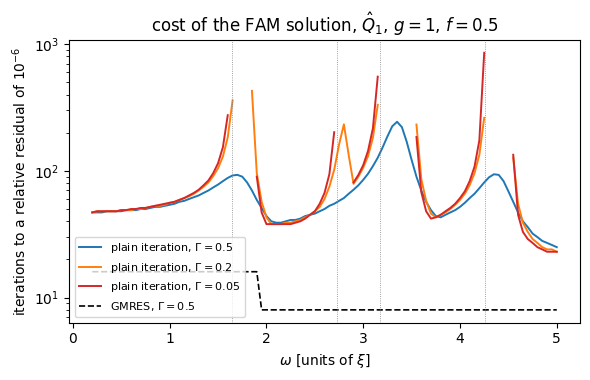

In [10]:
fock, mf = fam.setup()
solver = fam.FiniteAmplitudeMethod(mf)
matrix = fam.MatrixResponse(mf)
F = mf.to_hf_basis(fam.field_hopping(fock.L))
omegas = np.linspace(0.2, 5.0, 97)
fig, ax = plt.subplots(figsize=(6.0, 3.9))
for gamma, color in ((0.5, "C0"), (0.2, "C1"), (0.05, "C3")):
    its = []
    for w in omegas:
        _, _, it, res = solver.solve(F, w + 0.5j * gamma, method="fixed",
                                     tol=1e-6, mixing=0.5, maxiter=2000)
        its.append(it if res < 1e-6 else np.nan)
    ax.semilogy(omegas, its, color=color, lw=1.4, label=rf"plain iteration, $\Gamma={gamma}$")
its = [solver.solve(F, w + 0.25j, method="gmres", tol=1e-6)[2] for w in omegas]
ax.semilogy(omegas, its, color="k", lw=1.2, ls="--", label=r"GMRES, $\Gamma=0.5$")
for w in np.unique(np.round(matrix.omega, 6)):
    ax.axvline(w, color="gray", lw=0.6, ls=":")
ax.set_xlabel(r"$\omega$ [units of $\xi$]")
ax.set_ylabel("iterations to a relative residual of $10^{-6}$")
ax.set_title(r"cost of the FAM solution, $\hat Q_1$, $g=1$, $f=0.5$")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout(); plt.show()

Gaps in the plain-iteration curves are frequencies at which the iteration
diverges.  The dotted lines are the RPA roots.  Whether the plain iteration
converges at all is decided by the spectral radius of the iteration map, which
is set by the residual interaction divided by $|\omega-\Delta_{mi}|$; a Krylov
solver has no such restriction, which is why the paper -- with millions of
unknowns -- uses one.

## What to do next

The tasks of Project 1 in Appendix A start from here: vary $\eta$ and the
difference scheme, change the external field, follow the lowest pole as a
function of $f$ by contour integration alone, and then move on to the two
open-ended parts -- the Nambu-Goldstone mode of the number operator in the
QRPA of Chapter 7, and a coordinate-space Hartree-Fock code that would allow
the $^{20}$Ne calculation of the paper itself.